In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Imbalance"


%cd /content/drive/MyDrive/Imbalance


Mounted at /content/drive
/content/drive/MyDrive/Imbalance


In [ ]:
import os, json, math, time, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

import random, json, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pin = (device.type == 'cuda')

print("Device:", device)


Device: cuda


In [ ]:
CONFIG = {

    "epochs": 50,
    "batch_size": 128,
    "lr": 0.1,
    "backbones": ["resnet18", "densenet121"],
    "scenarios": ["lt", "ss", "as"],
    "tag_wrs": "wrs",
    "tag_ros": "ros",
    "seed": 0,
}
print(CONFIG)

# Reproducibility
import random
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CONFIG["seed"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


{'epochs': 50, 'batch_size': 128, 'lr': 0.1, 'backbones': ['resnet18', 'densenet121'], 'scenarios': ['lt', 'ss', 'as'], 'tag_wrs': 'wrs', 'tag_ros': 'ros', 'seed': 0}


cifar-10 dataset

In [ ]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])




train_data = datasets.CIFAR10("./dataset_cache", train=True,  download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train:", len(train_data), " Test:", len(test_data))


Train: 50000  Test: 10000


Load the split (LT/SS/AS) you created in data_splits.ipynb

In [ ]:
# We load all three split files into a dictionary so we can iterate
SPLITS = {}

for scn in ["lt", "ss", "as"]:
    p = os.path.join("splits", f"{scn}.json")
    if os.path.exists(p):
        with open(p) as f:
            data = json.load(f)
        SPLITS[scn] = {
            "indices": data["indices"],
            "counts": {int(k): int(v) for k,v in data["counts"].items()}
        }
        print(f"Loaded split '{scn.upper()}': {len(SPLITS[scn]['indices'])} images")
    else:
        print(f"WARNING: splits/{scn}.json not found — skipping this scenario.")

assert len(SPLITS) > 0, "No split files found. Run your data_splits notebook first."


Loaded split 'LT': 16191 images
Loaded split 'SS': 27500 images
Loaded split 'AS': 9500 images


DataLoaders, models, metrics, train/eval

In [ ]:
# --- DataLoader from indices (BASELINE: no sampler, just shuffle) ---
def make_train_loader_from_indices(dataset, indices, batch_size=128):
    subset = Subset(dataset, indices)
    pin = (device.type == "cuda")
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=pin)

def make_test_loader(dataset):
    pin = (device.type == "cuda")
    return DataLoader(dataset, batch_size=256, shuffle=False,
                      num_workers=2, pin_memory=pin)

test_loader = make_test_loader(test_data)

 #====== backbone======
def resnet18_cifar(num_classes=10):
    m = torchvision.models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = torchvision.models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_model(name, num_classes=10):
    name = name.lower()
    if name == "resnet18":    return resnet18_cifar(num_classes)
    if name == "densenet121": return densenet121_cifar(num_classes)
    raise ValueError("Unknown backbone: " + name)

# --- Metrics: confusion matrix, macro-F1, balanced accuracy ---
@torch.no_grad()

def get_preds(model, loader, device):
    model.eval()
    ys, yp = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu()
        ys.append(y.cpu())
        yp.append(pred)
    ys = torch.cat(ys).numpy()
    yp = torch.cat(yp).numpy()
    return ys, yp


def confusion_matrix(y_true, y_pred, K=10):
    cm = np.zeros((K,K), dtype=np.int64)
    for t,p in zip(y_true, y_pred): cm[t,p] += 1
    return cm

def macro_f1(cm):
    f1s=[]
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fp = cm[:,c].sum()-tp
        fn = cm[c,:].sum()-tp
        prec = tp/(tp+fp+1e-12)
        rec  = tp/(tp+fn+1e-12)
        f1s.append(2*prec*rec/(prec+rec+1e-12))
    return float(np.mean(f1s))

def balanced_acc(cm):
    recalls=[]
    for c in range(cm.shape[0]):
        tp = cm[c,c]; fn = cm[c,:].sum()-tp
        recalls.append(tp/(tp+fn+1e-12))
    return float(np.mean(recalls))

# --- Train / Eval one epoch ---
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total=0; correct=0; loss_sum=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        loss_sum += loss.item()
        total    += y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
    return loss_sum/len(loader), correct/total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total=0; correct=0; loss_sum=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item()
        total    += y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
    return loss_sum/len(loader), correct/total

# --- plot curves ---
def plot_curves(history, title=""):
    xs = range(1, len(history["train_acc"])+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(xs, history["train_loss"], label="train")
    plt.plot(xs, history["val_loss"],   label="val")
    plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(xs, np.array(history["train_acc"])*100, label="train")
    plt.plot(xs, np.array(history["val_acc"])*100,   label="val")
    plt.title("Accuracy"); plt.xlabel("epoch"); plt.ylabel("%"); plt.legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()


In [ ]:
SPLITS = {}
for name in ["lt","ss","as"]:
    path = os.path.join("splits", f"{name}.json")
    assert os.path.exists(path), f"Missing split file: {path}"
    with open(path) as f:
        SPLITS[name] = json.load(f)
print("Loaded splits:", list(SPLITS.keys()))


Loaded splits: ['lt', 'ss', 'as']



    Random Oversampling (with replacement) to match the majority count.
    We create a new index list by duplicating minority samples up to the head class size.
    Use for LT and SS. Avoid for AS.
    


    WeightedRandomSampler: sample rarer classes more often per batch.
    Use for LT and SS. Avoid for AS.
    

In [ ]:
def make_plain_loader(train_ds, indices, batch_size=128):
    subset = Subset(train_ds, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=4, pin_memory=pin)

def make_wrs_loader(train_ds, indices, counts, batch_size=128):

    subset = Subset(train_ds, indices)
    K = 10
    arr = np.array([counts.get(i,0) for i in range(K)], dtype=np.float64)
    inv = 1.0 / np.maximum(arr, 1.0)
    y_all = np.array(train_ds.targets)[np.array(indices)]
    w = inv[y_all]
    sampler = WeightedRandomSampler(
        torch.as_tensor(w, dtype=torch.double),
        num_samples=len(w), replacement=True
    )
    return DataLoader(subset, batch_size=batch_size, sampler=sampler,
                      num_workers=4, pin_memory=pin)

def make_ros_loader(train_ds, indices, counts, batch_size=128):

    K = 10
    idx = np.array(indices)
    y  = np.array(train_ds.targets)[idx]
    per_class = {c: idx[y==c] for c in range(K)}
    # target = max class size in THIS split
    target_n = max(len(v) for v in per_class.values() if len(v)>0)
    new_indices = []
    rng = np.random.default_rng(CONFIG["seed"])
    for c in range(K):
        orig = per_class.get(c, np.array([], dtype=int))
        if len(orig)==0:
            continue
        if len(orig) >= target_n:
            # if already ≥ target_n, sample exactly target_n without replacement
            sel = rng.choice(orig, target_n, replace=False)
        else:
            # sample WITH replacement to reach target_n
            extra = target_n - len(orig)
            dup   = rng.choice(orig, extra, replace=True)
            sel   = np.concatenate([orig, dup])
        new_indices.append(sel)
    new_indices = np.concatenate(new_indices)
    rng.shuffle(new_indices)
    subset = Subset(train_ds, new_indices.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=4, pin_memory=pin)



================  WRS | Scenario: LT  ================

--- LT | resnet18 | wrs (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.279 acc=23.4%  val_loss=1.775 acc=33.9%
Ep 05 | train_loss=1.260 acc=53.9%  val_loss=1.594 acc=44.2%
Ep 10 | train_loss=0.815 acc=71.2%  val_loss=1.131 acc=63.2%
Ep 15 | train_loss=0.519 acc=81.6%  val_loss=0.971 acc=71.4%
Ep 20 | train_loss=0.358 acc=87.4%  val_loss=0.881 acc=74.1%
Ep 25 | train_loss=0.250 acc=91.4%  val_loss=0.843 acc=76.3%
Ep 30 | train_loss=0.144 acc=95.1%  val_loss=0.747 acc=80.0%
Ep 35 | train_loss=0.074 acc=97.5%  val_loss=0.929 acc=77.8%
Ep 40 | train_loss=0.025 acc=99.3%  val_loss=0.799 acc=81.3%
Ep 45 | train_loss=0.015 acc=99.7%  val_loss=0.919 acc=80.2%
Ep 50 | train_loss=0.012 acc=99.7%  val_loss=0.891 acc=80.5%
Final test — Acc 81.26% | Macro-F1 81.44% | Balanced Acc 81.26%

--- Classification report: LT | resnet18 | wrs ---
              precision    recall  f1-score   support

    airplane       0.71      0.93      0.81      1000
  automobile       0.80      0.98      0.88      1000
        bird       0.78      0.81      0.79      1

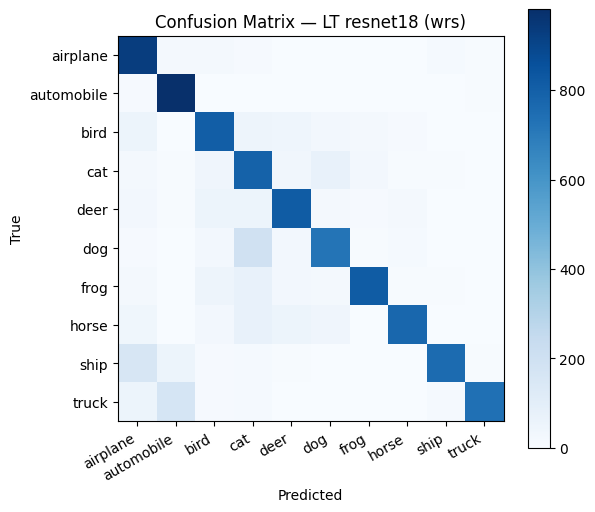

Saved confusion matrix: figures/cm_resnet18_LT_wrs.png


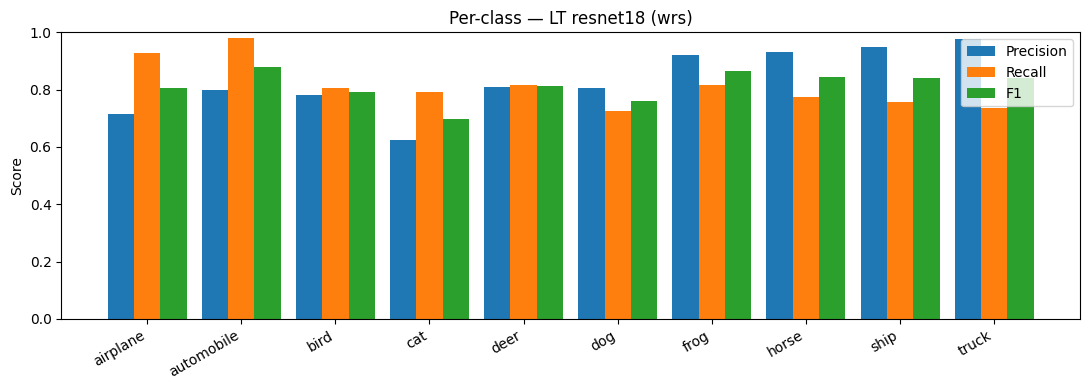

Saved per-class bars: figures/perclass_resnet18_LT_wrs.png

--- LT | densenet121 | wrs (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.963 acc=31.0%  val_loss=1.717 acc=36.8%
Ep 05 | train_loss=0.954 acc=66.2%  val_loss=2.037 acc=51.2%
Ep 10 | train_loss=0.560 acc=80.8%  val_loss=1.317 acc=64.3%
Ep 15 | train_loss=0.352 acc=87.9%  val_loss=0.982 acc=71.9%
Ep 20 | train_loss=0.241 acc=91.7%  val_loss=1.120 acc=72.4%
Ep 25 | train_loss=0.172 acc=94.1%  val_loss=1.135 acc=72.7%
Ep 30 | train_loss=0.089 acc=97.1%  val_loss=0.941 acc=77.0%
Ep 35 | train_loss=0.041 acc=98.7%  val_loss=0.891 acc=79.8%
Ep 40 | train_loss=0.014 acc=99.6%  val_loss=0.911 acc=80.3%
Ep 45 | train_loss=0.007 acc=99.8%  val_loss=0.848 acc=81.3%
Ep 50 | train_loss=0.006 acc=99.9%  val_loss=0.877 acc=81.2%
Final test — Acc 81.93% | Macro-F1 82.08% | Balanced Acc 81.93%

--- Classification report: LT | densenet121 | wrs ---
              precision    recall  f1-score   support

    airplane       0.70      0.94      0.80      1000
  automobile       0.82      0.98      0.89      1000
        bird       0.71      0.86      0.78    

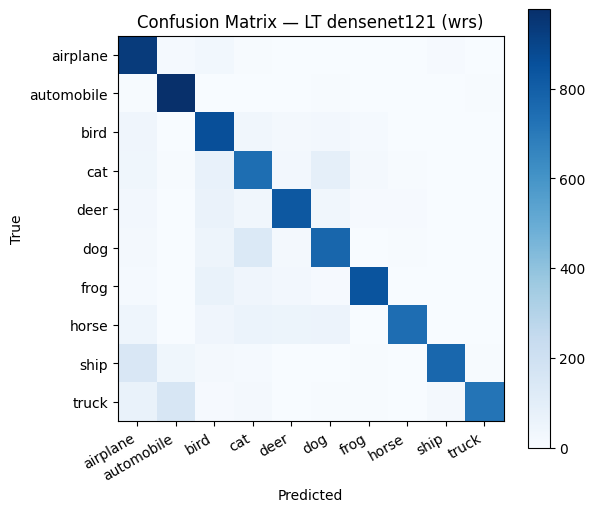

Saved confusion matrix: figures/cm_densenet121_LT_wrs.png


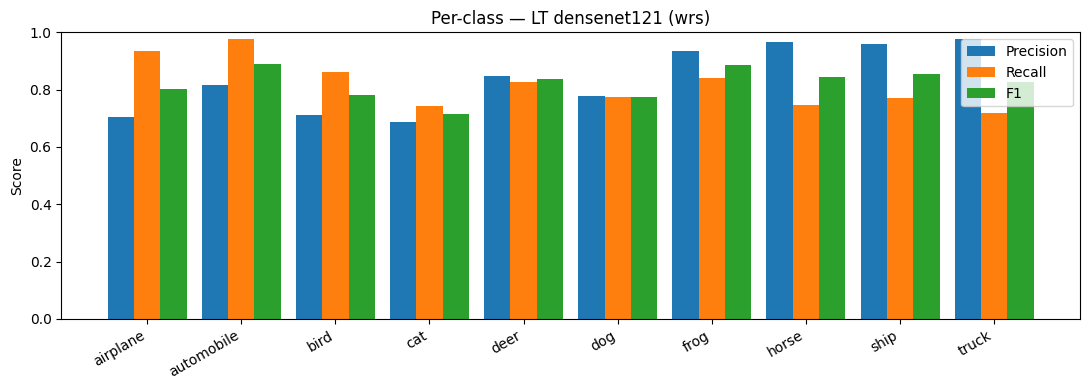

Saved per-class bars: figures/perclass_densenet121_LT_wrs.png

================  WRS | Scenario: SS  ================

--- SS | resnet18 | wrs (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.331 acc=20.1%  val_loss=1.793 acc=33.4%
Ep 05 | train_loss=1.184 acc=56.9%  val_loss=1.225 acc=56.5%
Ep 10 | train_loss=0.585 acc=79.3%  val_loss=1.201 acc=65.5%
Ep 15 | train_loss=0.378 acc=87.3%  val_loss=0.704 acc=78.2%
Ep 20 | train_loss=0.254 acc=91.5%  val_loss=0.720 acc=78.3%
Ep 25 | train_loss=0.189 acc=93.6%  val_loss=0.697 acc=81.1%
Ep 30 | train_loss=0.126 acc=95.8%  val_loss=0.627 acc=83.6%
Ep 35 | train_loss=0.069 acc=97.7%  val_loss=0.707 acc=82.9%
Ep 40 | train_loss=0.032 acc=99.0%  val_loss=0.735 acc=83.6%
Ep 45 | train_loss=0.014 acc=99.6%  val_loss=0.754 acc=83.9%
Ep 50 | train_loss=0.012 acc=99.7%  val_loss=0.772 acc=83.7%
Final test — Acc 84.27% | Macro-F1 84.30% | Balanced Acc 84.27%

--- Classification report: SS | resnet18 | wrs ---
              precision    recall  f1-score   support

    airplane       0.79      0.94      0.86      1000
  automobile       0.87      0.97      0.92      1000
        bird       0.76      0.90      0.83      1

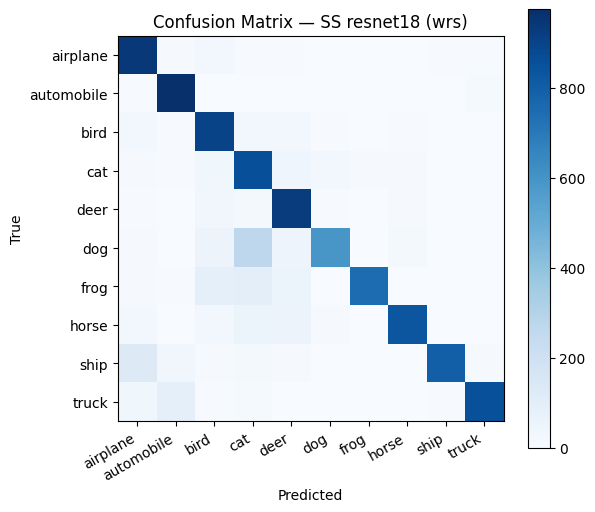

Saved confusion matrix: figures/cm_resnet18_SS_wrs.png


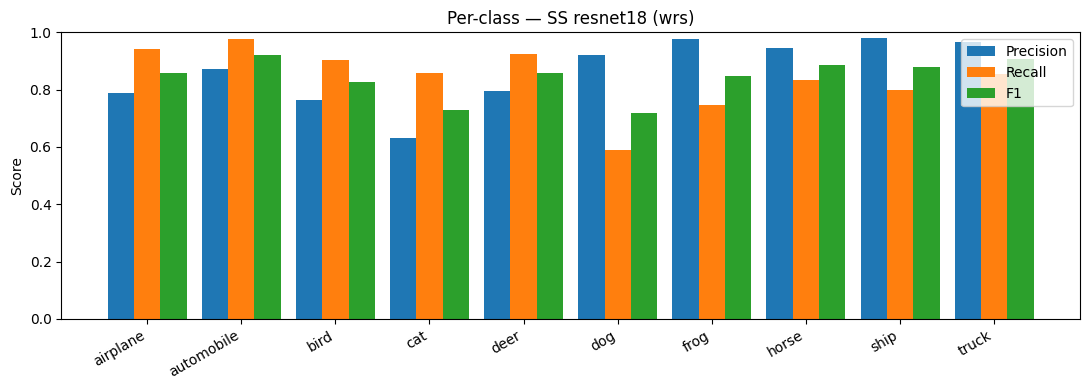

Saved per-class bars: figures/perclass_resnet18_SS_wrs.png

--- SS | densenet121 | wrs (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.754 acc=36.8%  val_loss=2.370 acc=37.2%
Ep 05 | train_loss=0.683 acc=75.9%  val_loss=1.109 acc=65.8%
Ep 10 | train_loss=0.344 acc=88.3%  val_loss=0.736 acc=78.1%
Ep 15 | train_loss=0.262 acc=91.2%  val_loss=0.688 acc=79.7%
Ep 20 | train_loss=0.202 acc=93.1%  val_loss=0.968 acc=76.0%
Ep 25 | train_loss=0.155 acc=94.9%  val_loss=0.638 acc=82.5%
Ep 30 | train_loss=0.102 acc=96.5%  val_loss=0.761 acc=81.8%
Ep 35 | train_loss=0.053 acc=98.2%  val_loss=0.706 acc=84.4%
Ep 40 | train_loss=0.023 acc=99.3%  val_loss=0.731 acc=84.9%
Ep 45 | train_loss=0.008 acc=99.8%  val_loss=0.813 acc=85.4%
Ep 50 | train_loss=0.006 acc=99.9%  val_loss=0.813 acc=85.6%
Final test — Acc 86.05% | Macro-F1 86.11% | Balanced Acc 86.05%

--- Classification report: SS | densenet121 | wrs ---
              precision    recall  f1-score   support

    airplane       0.82      0.94      0.88      1000
  automobile       0.90      0.97      0.93      1000
        bird       0.76      0.91      0.83    

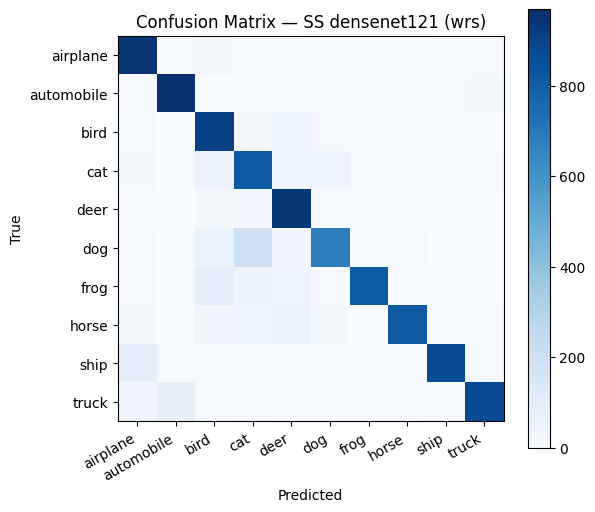

Saved confusion matrix: figures/cm_densenet121_SS_wrs.png


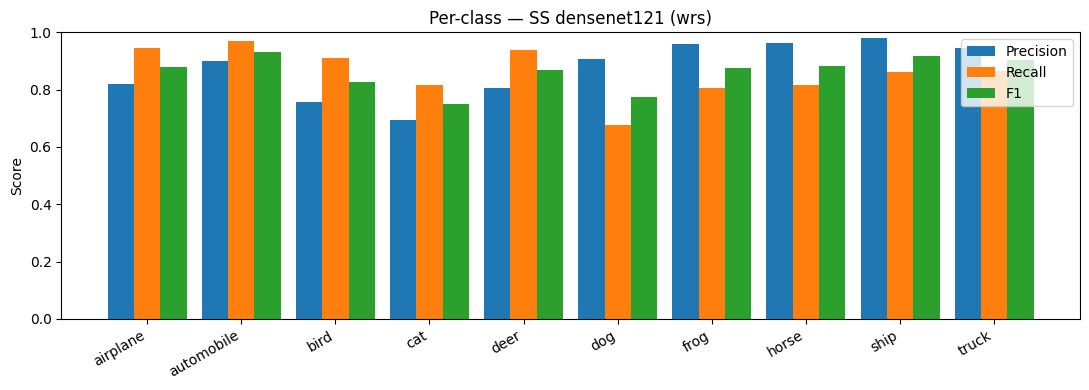

Saved per-class bars: figures/perclass_densenet121_SS_wrs.png

[SKIP] Scenario AS is skipped for WRS (not recommended).

================  ROS | Scenario: LT  ================

--- LT | resnet18 | ros (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.018 acc=29.7%  val_loss=1.581 acc=41.1%
Ep 05 | train_loss=0.680 acc=76.0%  val_loss=0.960 acc=68.3%
Ep 10 | train_loss=0.320 acc=89.1%  val_loss=1.064 acc=71.2%
Ep 15 | train_loss=0.214 acc=92.7%  val_loss=0.886 acc=76.2%
Ep 20 | train_loss=0.154 acc=94.8%  val_loss=0.836 acc=77.6%
Ep 25 | train_loss=0.104 acc=96.6%  val_loss=0.973 acc=76.3%
Ep 30 | train_loss=0.057 acc=98.2%  val_loss=0.887 acc=79.1%
Ep 35 | train_loss=0.014 acc=99.6%  val_loss=0.935 acc=78.4%
Ep 40 | train_loss=0.003 acc=100.0%  val_loss=0.724 acc=82.5%
Ep 45 | train_loss=0.002 acc=100.0%  val_loss=0.722 acc=82.3%
Ep 50 | train_loss=0.002 acc=100.0%  val_loss=0.708 acc=82.4%
Final test — Acc 82.68% | Macro-F1 82.80% | Balanced Acc 82.68%

--- Classification report: LT | resnet18 | ros ---
              precision    recall  f1-score   support

    airplane       0.68      0.97      0.80      1000
  automobile       0.79      0.99      0.88      1000
        bird       0.76      0.89      0.82    

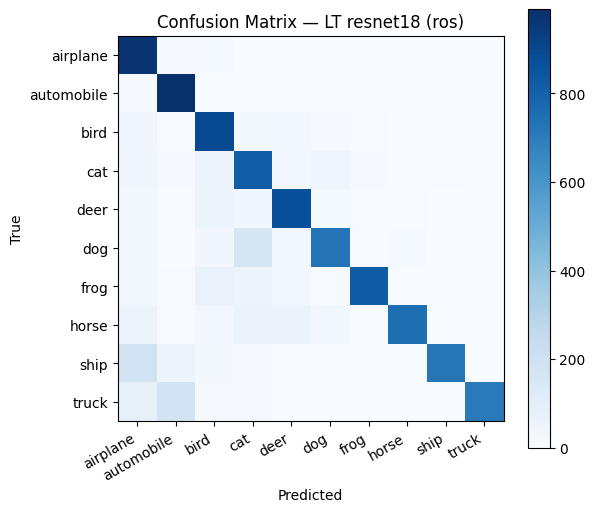

Saved confusion matrix: figures/cm_resnet18_LT_ros.png


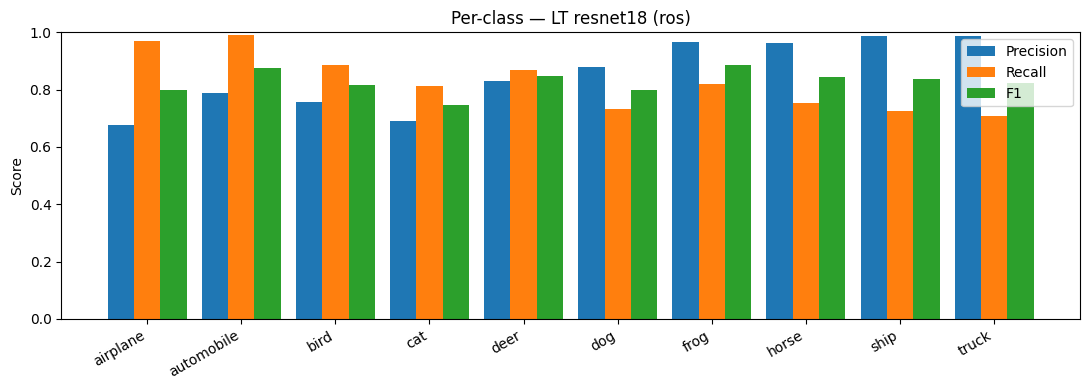

Saved per-class bars: figures/perclass_resnet18_LT_ros.png

--- LT | densenet121 | ros (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.560 acc=43.5%  val_loss=1.704 acc=43.2%
Ep 05 | train_loss=0.395 acc=86.4%  val_loss=0.871 acc=74.4%
Ep 10 | train_loss=0.232 acc=92.1%  val_loss=1.188 acc=69.1%
Ep 15 | train_loss=0.187 acc=93.7%  val_loss=0.701 acc=80.3%
Ep 20 | train_loss=0.135 acc=95.5%  val_loss=0.834 acc=78.1%
Ep 25 | train_loss=0.094 acc=96.9%  val_loss=0.668 acc=82.1%
Ep 30 | train_loss=0.056 acc=98.2%  val_loss=0.819 acc=81.0%
Ep 35 | train_loss=0.020 acc=99.4%  val_loss=0.863 acc=81.4%
Ep 40 | train_loss=0.004 acc=99.9%  val_loss=0.714 acc=84.6%
Ep 45 | train_loss=0.002 acc=100.0%  val_loss=0.688 acc=85.2%
Ep 50 | train_loss=0.001 acc=100.0%  val_loss=0.708 acc=85.1%
Final test — Acc 85.32% | Macro-F1 85.42% | Balanced Acc 85.32%

--- Classification report: LT | densenet121 | ros ---
              precision    recall  f1-score   support

    airplane       0.76      0.96      0.85      1000
  automobile       0.82      0.99      0.90      1000
        bird       0.77      0.90      0.83  

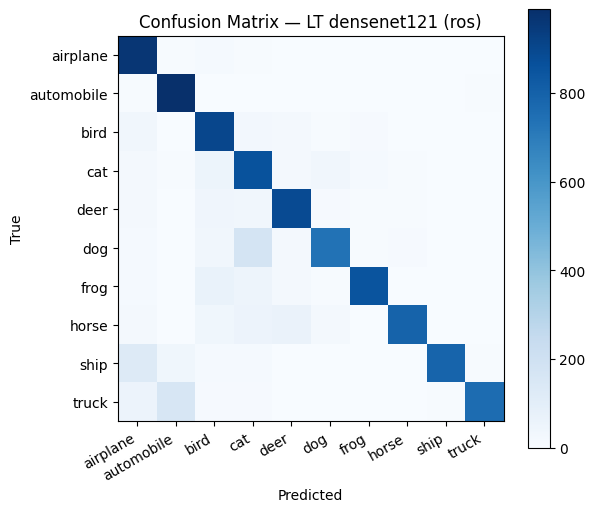

Saved confusion matrix: figures/cm_densenet121_LT_ros.png


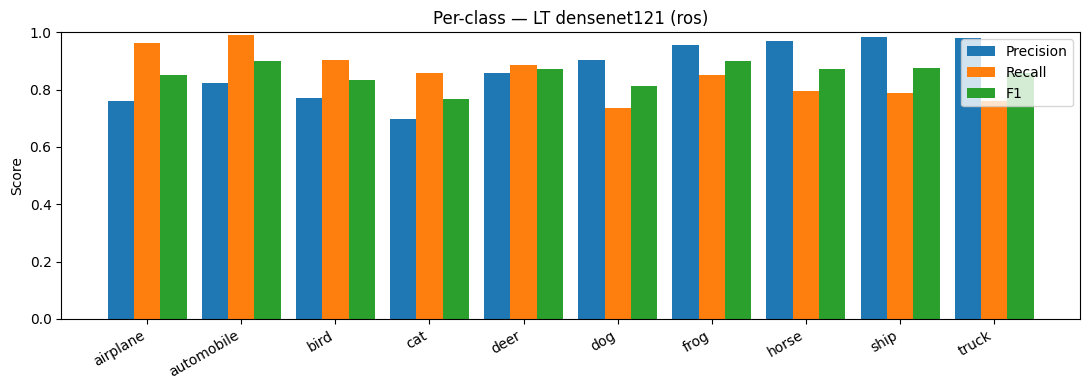

Saved per-class bars: figures/perclass_densenet121_LT_ros.png

================  ROS | Scenario: SS  ================

--- SS | resnet18 | ros (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.078 acc=26.2%  val_loss=1.661 acc=38.5%
Ep 05 | train_loss=0.724 acc=74.6%  val_loss=0.988 acc=67.0%
Ep 10 | train_loss=0.355 acc=87.8%  val_loss=0.750 acc=77.4%
Ep 15 | train_loss=0.259 acc=91.2%  val_loss=1.070 acc=72.2%
Ep 20 | train_loss=0.196 acc=93.3%  val_loss=1.042 acc=73.6%
Ep 25 | train_loss=0.146 acc=95.1%  val_loss=0.755 acc=81.4%
Ep 30 | train_loss=0.095 acc=96.8%  val_loss=0.838 acc=79.8%
Ep 35 | train_loss=0.049 acc=98.4%  val_loss=0.633 acc=85.3%
Ep 40 | train_loss=0.013 acc=99.7%  val_loss=0.716 acc=84.6%
Ep 45 | train_loss=0.004 acc=99.9%  val_loss=0.697 acc=85.0%
Ep 50 | train_loss=0.003 acc=100.0%  val_loss=0.703 acc=85.3%
Final test — Acc 85.72% | Macro-F1 85.75% | Balanced Acc 85.72%

--- Classification report: SS | resnet18 | ros ---
              precision    recall  f1-score   support

    airplane       0.84      0.96      0.89      1000
  automobile       0.88      0.98      0.93      1000
        bird       0.80      0.93      0.86      

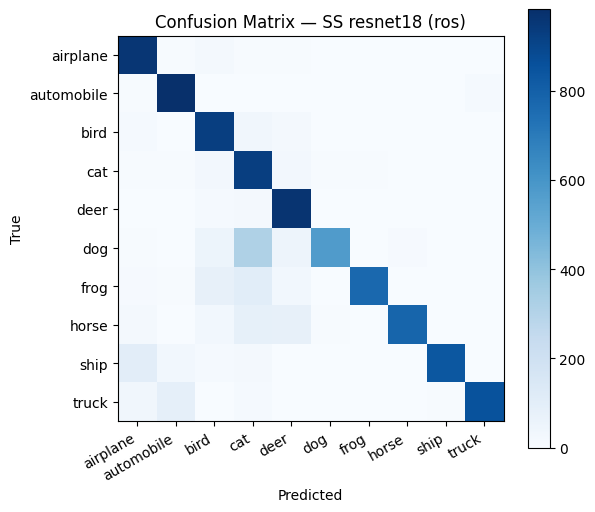

Saved confusion matrix: figures/cm_resnet18_SS_ros.png


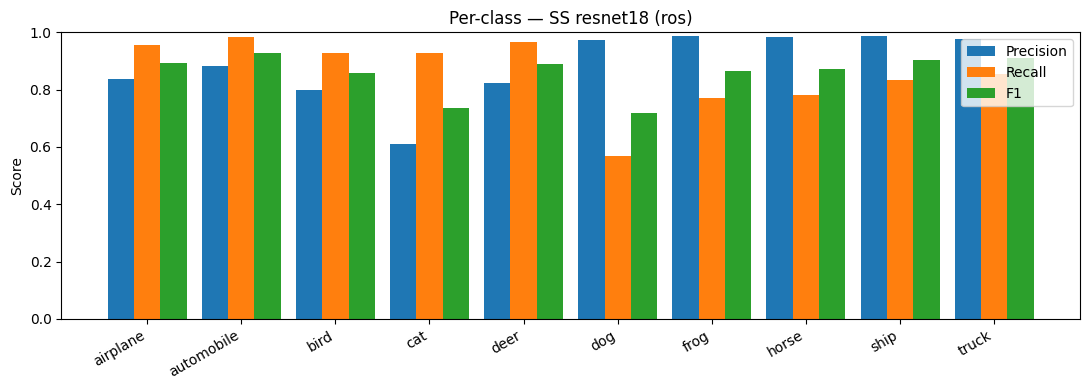

Saved per-class bars: figures/perclass_resnet18_SS_ros.png

--- SS | densenet121 | ros (CE loss) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.578 acc=43.5%  val_loss=1.357 acc=53.0%
Ep 05 | train_loss=0.447 acc=84.7%  val_loss=0.794 acc=76.2%
Ep 10 | train_loss=0.278 acc=90.5%  val_loss=0.756 acc=77.6%
Ep 15 | train_loss=0.224 acc=92.4%  val_loss=0.659 acc=80.9%
Ep 20 | train_loss=0.176 acc=94.0%  val_loss=0.769 acc=79.5%
Ep 25 | train_loss=0.137 acc=95.3%  val_loss=0.903 acc=79.5%
Ep 30 | train_loss=0.087 acc=97.1%  val_loss=0.742 acc=81.8%
Ep 35 | train_loss=0.041 acc=98.7%  val_loss=0.845 acc=82.6%
Ep 40 | train_loss=0.011 acc=99.7%  val_loss=0.746 acc=85.0%
Ep 45 | train_loss=0.003 acc=99.9%  val_loss=0.722 acc=86.2%
Ep 50 | train_loss=0.002 acc=100.0%  val_loss=0.745 acc=86.2%
Final test — Acc 87.39% | Macro-F1 87.40% | Balanced Acc 87.39%

--- Classification report: SS | densenet121 | ros ---
              precision    recall  f1-score   support

    airplane       0.85      0.97      0.91      1000
  automobile       0.89      0.99      0.93      1000
        bird       0.84      0.93      0.88   

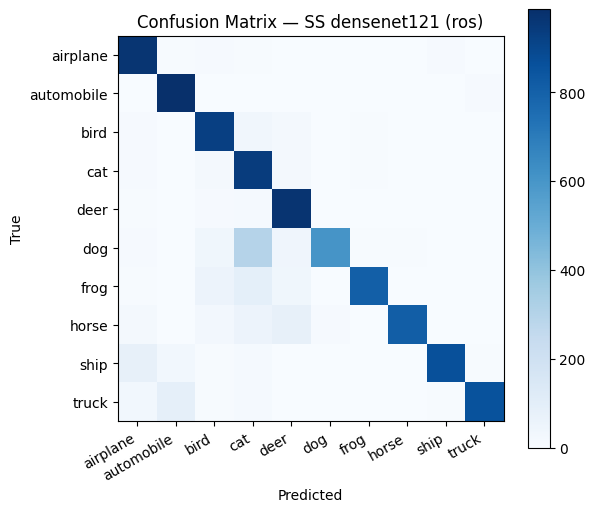

Saved confusion matrix: figures/cm_densenet121_SS_ros.png


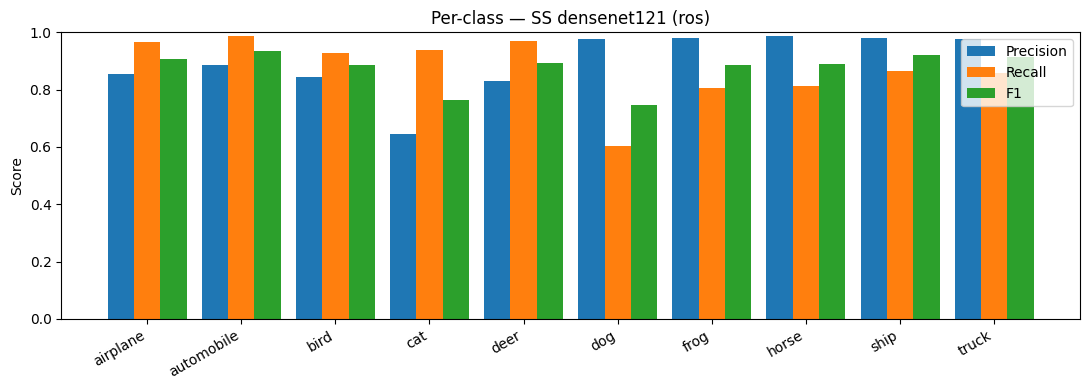

Saved per-class bars: figures/perclass_densenet121_SS_ros.png

[SKIP] Scenario AS is skipped for ROS (not recommended).


In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

def run_experiment(tag, make_loader_fn):

    summary_rows = []

    for scn_key, split in SPLITS.items():
        indices = split["indices"]
        counts  = {int(k):int(v) for k,v in split["counts"].items()}

        # We SKIP AS for WRS/ROS (not recommended there)
        if scn_key == "as":
            print(f"\n[SKIP] Scenario {scn_key.upper()} is skipped for {tag.upper()} (not recommended).")
            continue

        print(f"\n================  {tag.upper()} | Scenario: {scn_key.upper()}  ================")
        # Build loader with this technique
        train_loader = make_loader_fn(train_data, indices, counts, batch_size=CONFIG["batch_size"])

        for backbone in CONFIG["backbones"]:
            print(f"\n--- {scn_key.upper()} | {backbone} | {tag} (CE loss) ---")
            model = make_model(backbone, 10).to(device)
            criterion = nn.CrossEntropyLoss()
            opt   = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=0.9, weight_decay=5e-4)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"])

            best_val = -1.0; best_state = None
            history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

            for ep in range(1, CONFIG["epochs"]+1):
                tl, ta = train_one_epoch(model, train_loader, criterion, opt)
                vl, va = evaluate(model, test_loader,  criterion)
                sched.step()
                history["train_loss"].append(tl); history["train_acc"].append(ta)
                history["val_loss"].append(vl);   history["val_acc"].append(va)

                if va > best_val:
                    best_val = va
                    best_state = {k:v.cpu() for k,v in model.state_dict().items()}

                if ep==1 or ep%5==0:
                    print(f"Ep {ep:02d} | train_loss={tl:.3f} acc={ta*100:.1f}%  val_loss={vl:.3f} acc={va*100:.1f}%")

            # restore best and compute metrics
            if best_state: model.load_state_dict(best_state)
            y_true, y_pred = get_preds(model, test_loader, device)
            cm   = confusion_matrix(y_true, y_pred, K=10)
            acc  = (y_true == y_pred).mean()
            mF1  = macro_f1(cm)
            bAcc = balanced_acc(cm)
            print(f"Final test — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | Balanced Acc {bAcc*100:.2f}%")

            # Save checkpoint + metrics
            ckpt_path = os.path.join("ckpts", f"{backbone}_{scn_key.upper()}_{tag}.pt")
            torch.save(model.state_dict(), ckpt_path)

            met = {
                "scenario": scn_key.upper(),
                "backbone": backbone,
                "epochs":   CONFIG["epochs"],
                "test_acc": float(acc),
                "macro_f1": float(mF1),
                "balanced_acc": float(bAcc),
                "history":  history,
                "tag": tag
            }
            met_path = os.path.join("metrics", f"{backbone}_{scn_key.upper()}_{tag}.json")
            with open(met_path, "w") as f: json.dump(met, f, indent=2)

            # Classification report (print + save)
            report = classification_report(y_true, y_pred, target_names=class_labels, digits=2)
            print("\n--- Classification report:", f"{scn_key.upper()} | {backbone} | {tag} ---")
            print(report)
            rep_path = os.path.join("metrics", f"{backbone}_{scn_key.upper()}_{tag}_report.txt")
            with open(rep_path, "w") as f: f.write(report)
            print("Saved report:", rep_path)

            # Confusion matrix image
            plt.figure(figsize=(6.2,5.4))
            plt.imshow(cm, cmap="Blues", interpolation='nearest')
            plt.title(f"Confusion Matrix — {scn_key.upper()} {backbone} ({tag})")
            plt.colorbar()
            ticks = np.arange(len(class_labels))
            plt.xticks(ticks, class_labels, rotation=30, ha='right')
            plt.yticks(ticks, class_labels)
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            cm_path = os.path.join("figures", f"cm_{backbone}_{scn_key.upper()}_{tag}.png")
            plt.savefig(cm_path, dpi=180); plt.show()
            print("Saved confusion matrix:", cm_path)

            # Per-class bars
            prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=range(10), zero_division=0)
            x = np.arange(len(class_labels)); w = 0.28
            plt.figure(figsize=(11,4))
            plt.bar(x-w, prec, width=w, label='Precision')
            plt.bar(x,   rec,  width=w, label='Recall')
            plt.bar(x+w, f1,   width=w, label='F1')
            plt.ylim(0,1.0); plt.legend()
            plt.xticks(x, class_labels, rotation=30, ha='right')
            plt.ylabel("Score"); plt.title(f"Per-class — {scn_key.upper()} {backbone} ({tag})")
            plt.tight_layout()
            bars_path = os.path.join("figures", f"perclass_{backbone}_{scn_key.upper()}_{tag}.png")
            plt.savefig(bars_path, dpi=180); plt.show()
            print("Saved per-class bars:", bars_path)

            # Collect for summary
            summary_rows.append([scn_key.upper(), backbone, round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)])


# --- Run WRS (LT/SS only) ---
run_experiment(CONFIG["tag_wrs"], make_wrs_loader)

# --- Run ROS (LT/SS only) ---
run_experiment(CONFIG["tag_ros"], make_ros_loader)
